<a href="https://colab.research.google.com/github/STRIKER-oss/Denisov_m25_555_PR1/blob/main/%D0%A1V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import networkx as nx
from google.colab import files

In [3]:
uploaded = files.upload()

for name, data in uploaded.items():
    with open(os.path.join("images", name), "wb") as f:
        f.write(data)

Saving Bosmina longirostris 3.jpg to Bosmina longirostris 3.jpg
Saving Bosmina longirostris 6.jpg to Bosmina longirostris 6.jpg
Saving Bosmina longirostris 2.jpg to Bosmina longirostris 2.jpg
Saving Bosmina longirostris 1.jpg to Bosmina longirostris 1.jpg
Saving Bosmina longirostris 5.jpg to Bosmina longirostris 5.jpg
Saving Bosmina longirostris 4.jpg to Bosmina longirostris 4.jpg


In [4]:
image_paths = sorted(
    os.path.join("images", f) for f in os.listdir("images")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)
names = [os.path.basename(p) for p in image_paths]

images = []
for p in image_paths:
    img = cv2.imread(p)
    h, w = img.shape[:2]
    if max(h, w) > 1000:
        s = 1000 / max(h, w)
        img = cv2.resize(img, (int(w*s), int(h*s)))
    images.append(img)


In [11]:
sift = cv2.SIFT_create(nfeatures=5000, contrastThreshold=0.03, edgeThreshold=20, sigma=1.6)
keypoints_list, descriptors_list = [], []
for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    keypoints_list.append(kp)
    descriptors_list.append(des)

for n, kp in zip(names, keypoints_list):
    print(f" {n}: {len(kp)} точек")

  Bosmina longirostris 1.jpg: 5000 точек
  Bosmina longirostris 2.jpg: 5001 точек
  Bosmina longirostris 3.jpg: 5000 точек
  Bosmina longirostris 4.jpg: 5000 точек
  Bosmina longirostris 5.jpg: 5000 точек
  Bosmina longirostris 6.jpg: 285 точек


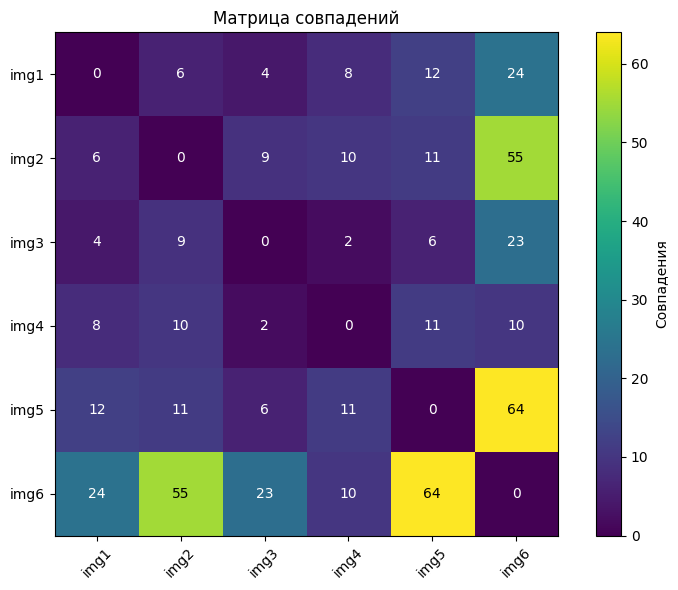

In [13]:
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=150))
RATIO = 0.75
RANSAC_THRESH = 8.0

def match_pair(i, j):
    d1, d2 = descriptors_list[i], descriptors_list[j]
    raw = flann.knnMatch(d1, d2, k=2)
    good = []
    for pair in raw:
        if len(pair) < 2:
            continue
        m, nn = pair
        if m.distance < RATIO * nn.distance:
            good.append(m)
    if len(good) < 4:
        return []
    src = np.float32([keypoints_list[i][m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([keypoints_list[j][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, RANSAC_THRESH)
    if mask is None:
        return []
    return [g for g, ok in zip(good, mask.ravel()) if ok]

total = len(images)
pair_matches = {}
match_matrix = np.zeros((total, total), dtype=int)

for i in range(total):
    for j in range(i + 1, total):
        m = match_pair(i, j)
        pair_matches[(i, j)] = m
        pair_matches[(j, i)] = m
        match_matrix[i, j] = match_matrix[j, i] = len(m)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(match_matrix, cmap="viridis")
ax.set_xticks(range(total)); ax.set_xticklabels([f"img{i+1}" for i in range(total)], rotation=45)
ax.set_yticks(range(total)); ax.set_yticklabels([f"img{i+1}" for i in range(total)])
for i in range(total):
    for j in range(total):
        ax.text(j, i, match_matrix[i, j], ha="center", va="center",
                color="white" if match_matrix[i, j] < match_matrix.max()/2 else "black")
plt.colorbar(im, label="Совпадения")
plt.title("Матрица совпадений")
plt.tight_layout()
plt.savefig("match_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

In [7]:
G = nx.Graph()
for i in range(total):
    for k in range(len(keypoints_list[i])):
        G.add_node((i, k))
for (i, j), matches in pair_matches.items():
    for m in matches:
        G.add_edge((i, m.queryIdx), (j, m.trainIdx))

common_groups = []
for comp in nx.connected_components(G):
    per_img = {}
    for (img_i, kp_i) in comp:
        per_img.setdefault(img_i, []).append(kp_i)
    if len(per_img) == total:
        common_groups.append([(img_i, per_img[img_i][0]) for img_i in range(total)])

print(f"Общих точек на всех {total} изображениях: {len(common_groups)}")

Общих точек на всех 6 изображениях: 1


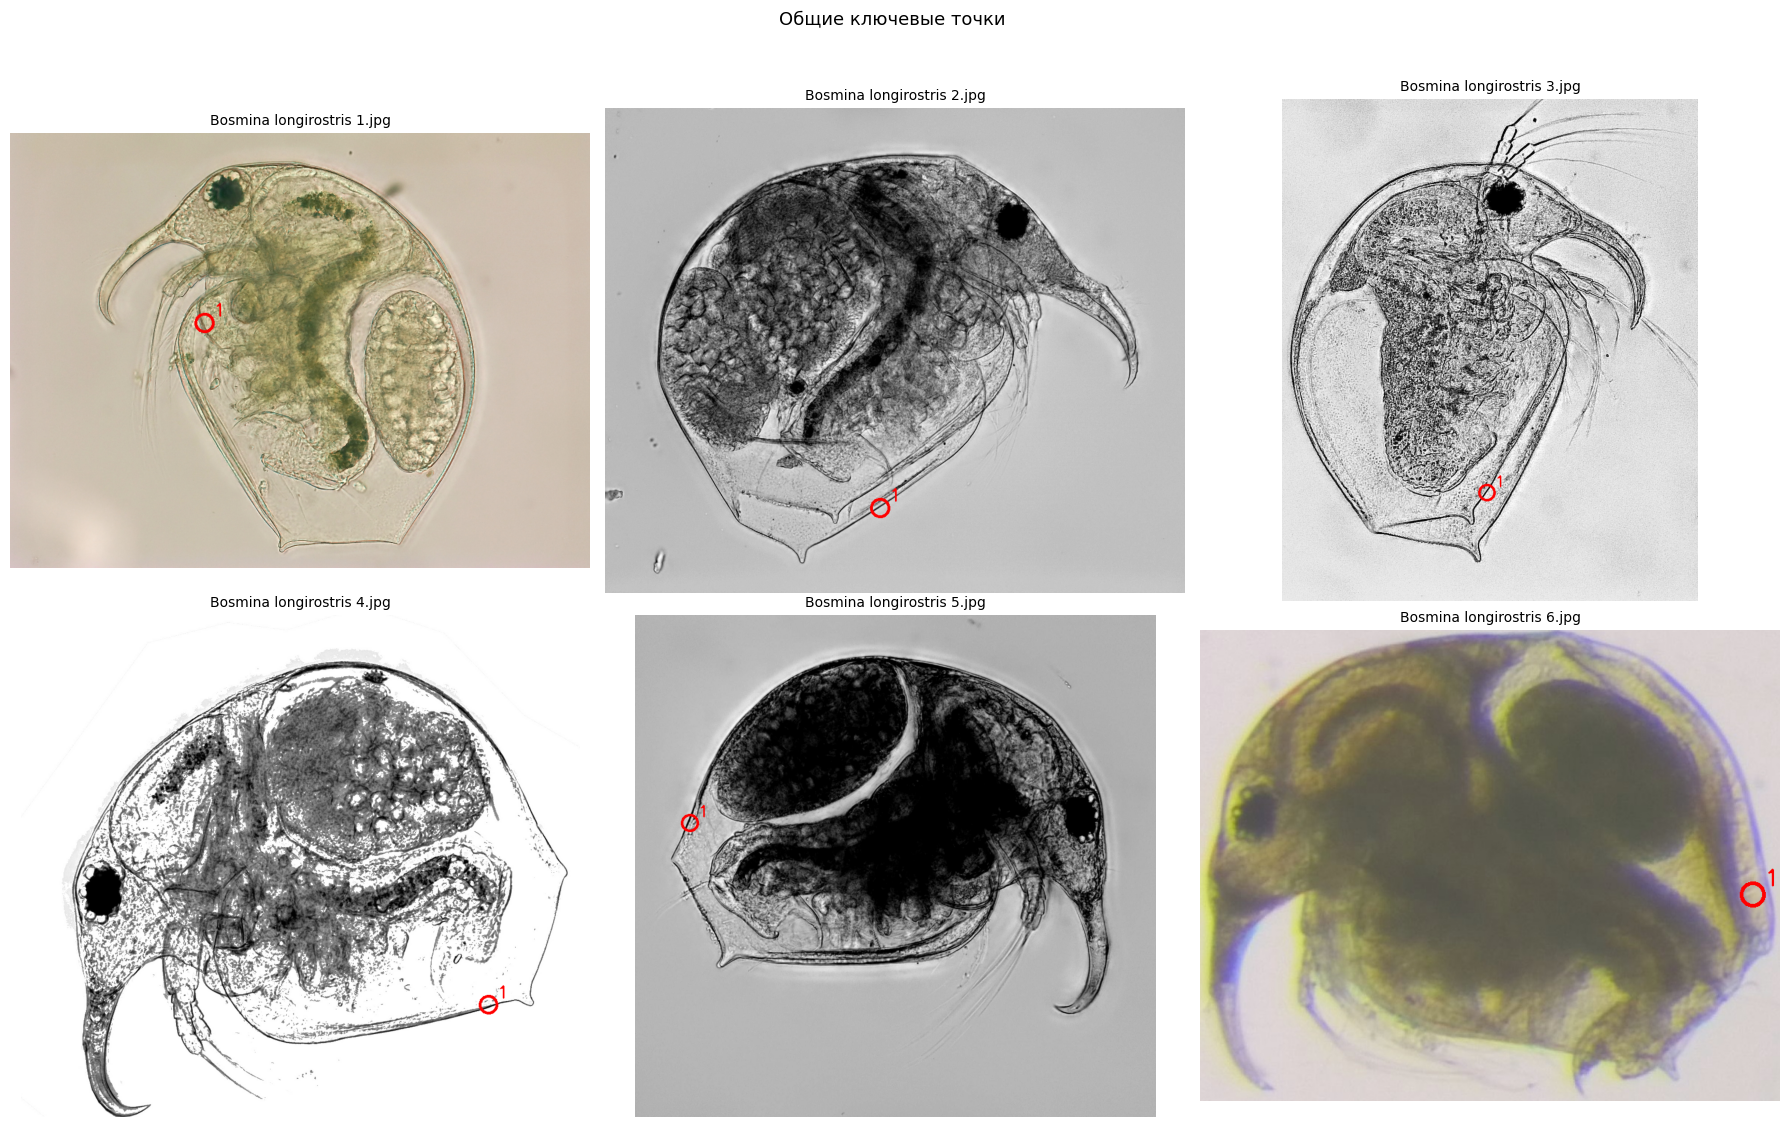

In [14]:
colors = [(0, 0, 255), (0, 180, 0), (255, 140, 0), (160, 32, 240), (0, 200, 200)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for idx, (ax, img, kps, name) in enumerate(zip(axes, images, keypoints_list, names)):
    vis = img.copy()
    for num, group in enumerate(common_groups, start=1):
        this = None
        for g in group:
            if g is not None and g[0] == idx:
                this = g[1]; break
        if this is None: continue
        x, y = map(int, kps[this].pt)
        color = colors[(num - 1) % len(colors)]
        cv2.circle(vis, (x, y), 15, color, 3)
        cv2.putText(vis, str(num), (x + 16, y - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.suptitle(f"Общие ключевые точки ", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("common_points.png", dpi=140, bbox_inches="tight")
plt.show()

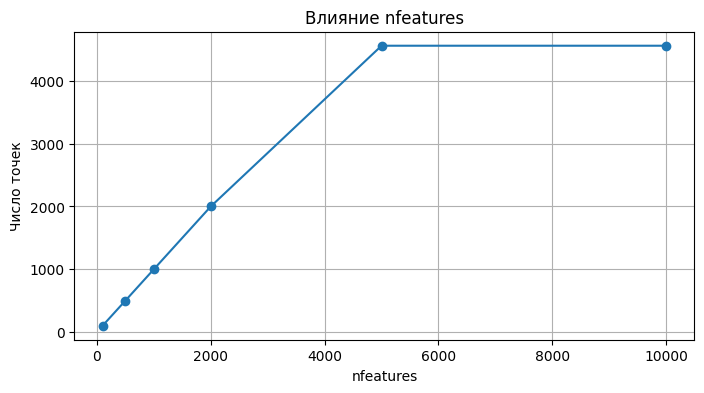

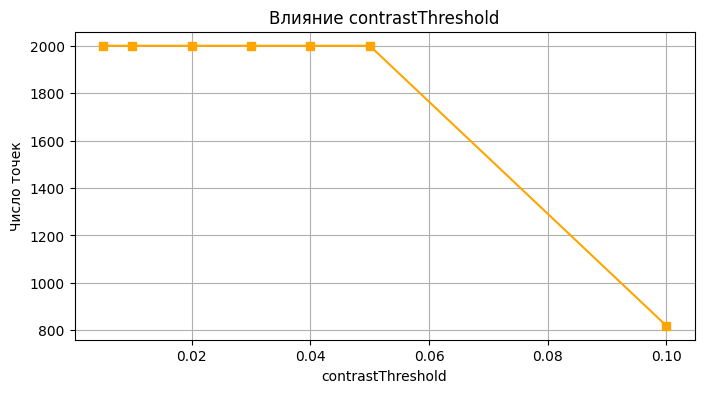

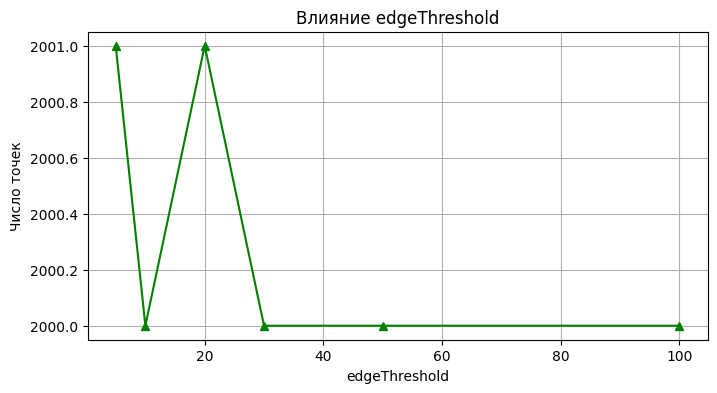

In [9]:
gray_sample = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY)

nfeat_values = [100, 500, 1000, 2000, 5000, 10000]
counts_nf = [len(cv2.SIFT_create(nfeatures=nf).detect(gray_sample, None)) for nf in nfeat_values]
plt.figure(figsize=(8, 4)); plt.plot(nfeat_values, counts_nf, "o-")
plt.xlabel("nfeatures"); plt.ylabel("Число точек")
plt.title("Влияние nfeatures"); plt.grid(True)
plt.savefig("param_nfeatures.png", dpi=120, bbox_inches="tight"); plt.show()

ct_values = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]
counts_ct = [len(cv2.SIFT_create(nfeatures=2000, contrastThreshold=ct).detect(gray_sample, None)) for ct in ct_values]
plt.figure(figsize=(8, 4)); plt.plot(ct_values, counts_ct, "s-", color="orange")
plt.xlabel("contrastThreshold"); plt.ylabel("Число точек")
plt.title("Влияние contrastThreshold"); plt.grid(True)
plt.savefig("param_ct.png", dpi=120, bbox_inches="tight"); plt.show()

et_values = [5, 10, 20, 30, 50, 100]
counts_et = [len(cv2.SIFT_create(nfeatures=2000, edgeThreshold=et).detect(gray_sample, None)) for et in et_values]
plt.figure(figsize=(8, 4)); plt.plot(et_values, counts_et, "^-", color="green")
plt.xlabel("edgeThreshold"); plt.ylabel("Число точек")
plt.title("Влияние edgeThreshold"); plt.grid(True)
plt.savefig("param_et.png", dpi=120, bbox_inches="tight"); plt.show()